# Importing Packages



In [82]:
import pandas as pd
import csv
import numpy as np
import sklearn
import imblearn

from numpy import loadtxt
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import *
from sklearn.cluster import KMeans
from sklearn.naive_bayes import GaussianNB
from sklearn.mixture import BayesianGaussianMixture
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier
from sklearn.mixture import BayesianGaussianMixture
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LinearRegression
from collections import Counter
from imblearn.over_sampling import BorderlineSMOTE
from sklearn import metrics
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import KFold
from sklearn.cluster import MiniBatchKMeans
from sklearn.linear_model import SGDClassifier
from sklearn.neural_network import MLPClassifier


# Mounting The Drive

In [83]:
# prompt: mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Loading the Dataset

In [185]:
#Location of the input dataset
# fileLocation ='/content/drive/MyDrive/VRSEC/III Year/Mini/Sahith/food-drug-dataset.csv'
# fileLocation ='/content/food-drug-dataset-balanced.csv'
# fileLocation ='/content/drive/MyDrive/Mini/food-drug-dataset.csv'
# fileLocation ='/content/food-drug-dataset-balanced-no-headers-v2.csv'
fileLocation ='/content/food-drug-dataset-balanced-corrupted-85.csv'

# Data Preprocessing

In [186]:
# df = pd.read_csv(fileLocation)
# # Count the Number of TRUE and FALSE in the Result column
# result_counts = df['Result'].value_counts()
# # # Save the dataset with headers
# # file_with_headers = "food-drug-dataset-with-headers.csv"
# # df.to_csv(file_with_headers, index=False)
# result_counts

In [187]:
# # Load the balanced dataset (with headers)
# balanced_df_with_headers = pd.read_csv(fileLocation)
# # Save it again without headers
# balanced_file_no_headers_2 = "food-drug-dataset-balanced-no-headers-v2.csv"
# balanced_df_with_headers.to_csv(balanced_file_no_headers_2, index=False, header=False)
# balanced_file_no_headers_2


In [188]:
# # # Separate True and False rows
# true_rows = df[df['Result'] == True]
# false_rows = df[df['Result'] == False].sample(n=len(true_rows), random_state=42)
# # # Combine and shuffle the balanced dataset
# balanced_df = pd.concat([true_rows, false_rows]).sample(frac=1, random_state=42)
# # # Save the balanced dataset
# balanced_file_path = "food-drug-dataset-balanced.csv"
# balanced_df.to_csv(balanced_file_path, index=False)
# balanced_df.shape

In [189]:
# #Converting the dataset from CSV to a numpy array for passing it as input to learning models
# def readDataFromFile(fileLocation):
#   interactionData = pd.read_csv(fileLocation,
#       names=['Food-id','Drug-id','Tanimoto','Dice','Cosine','Sokal','Tversky','Result'])
#   interactionArray = np.array(interactionData)
#   print(interactionArray[0])
#   return interactionArray

In [202]:
# def slightly_corrupt_labels(data_array, corruption_rate=0.50):
#     data_copy = np.copy(data_array)
#     total_samples = len(data_copy)
#     num_to_corrupt = int(total_samples * corruption_rate)
#     indices = np.random.choice(total_samples, num_to_corrupt, replace=False)

#     for idx in indices:
#         # Convert 'True'/'False' to 1/0 before flipping
#         current_val = data_copy[idx, -1]
#         data_copy[idx, -1] = 1 - (1 if current_val == 'True' else 0)
#     return data_copy

In [203]:
# # # Save the corrupted dataset without headers
# corrupted_file_path = "food-drug-dataset-balanced-corrupted.csv"
# pd.DataFrame(corrupted_array).to_csv(corrupted_file_path, index=False, header=False)

# corrupted_file_path

'food-drug-dataset-balanced-corrupted.csv'

In [190]:
#Converting the dataset from CSV to a numpy array for passing it as input to learning models
def readDataFromFile(fileLocation):
  interactionData = pd.read_csv(fileLocation,
      names=['Food-id','Drug-id','Tanimoto','Dice','Cosine','Sokal','Tversky','Result'])
  interactionArray = np.array(interactionData)
  print(interactionArray[0])
  return interactionArray

In [191]:
#calling the function to get data
interactionArray = readDataFromFile(fileLocation)

['FDB001982' 'DB09477' 0.099 0.179 0.213 0.052 0.201 'False']


# Model Training

In [192]:
#this function calculates the F1 score when test data input (y_test) and test data output(y_pred) values are given
def calculateF1Score(y_test, y_pred):
  weighted = f1_score(y_test, y_pred, average='weighted')
  return weighted

In [193]:
# #this function splits the dataset into training and testing data to feed the learning algorithm
# def prepareDataset(interactionArray):
#   X = interactionArray[:,2:7]
#   y = interactionArray[:,7]
#   y = y.astype(int)
#   X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)
#   return X_train, X_test, y_train, y_test

In [194]:
#this function splits the dataset into training and testing data to feed the learning algorithm
def prepareDataset(interactionArray):
  X = interactionArray[:,2:7]
  y = interactionArray[:,7]
  # Convert 'True' and 'False' strings to 1 and 0 respectively
  y = np.where(y == 'True', 1, 0)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)
  return X_train, X_test, y_train, y_test

In [195]:
# """ Prepare a dataset with k-folds. Currently taking k = 4.
# The dataset is divided into k number of groups, each group has an equal number of samples.
# The 'k-1' groups are used for the model to train and the other one-fold is used for testing the model.
# Parameters: an array consisting of all the interactions and their coefficients
# Returns: X_train, X_train, y_train, y_test are the array of training and testing datasets. Counter is number of k-splits."""
# def prepareDatasetKFold(interactionArray):
#   # Copy interactionArray into other array
#   array = np.copy(interactionArray)
#   # Splitting the array and taking only coeffecients, Tanimoto, Dice, Cosine, Sokal, Tversky indexes
#   X = array[:,2:7]
#   # Splitting the array and taking the labels as 'TRUE' or 'FALSE' values
#   y = interactionArray[:,7]
#   # Converting the 'TRUE' or 'FALSE' values into binary labels.
#   y = y.astype(int)

#   # Applying K-Fold cross validation
#   kf = KFold(n_splits=4)
#   kf.get_n_splits(X)

#   #Initializing X_train, X_test, y_train, y_test as empty arrays
#   X_train, X_test, y_train, y_test = [], [], [], []

#   # For each train and test index in split of X, y : Append X[train_index], y[train_index] to train dataset and X[test_index], y[test_index] to test dataset
#   for train_index, test_index in kf.split(X, y):
#     # print("TRAIN:", train_index, "TEST:", test_index)
#     X_train.append(X[train_index])
#     X_test.append(X[test_index])
#     y_train.append(y[train_index])
#     y_test.append(y[test_index])
#   # Return the test and train dataset with k-fold (currently 4)
#   return X_train, X_test, y_train, y_test, 4

In [196]:
""" Prepare a dataset with k-folds. Currently taking k = 4.
The dataset is divided into k number of groups, each group has an equal number of samples.
The 'k-1' groups are used for the model to train and the other one-fold is used for testing the model.
Parameters: an array consisting of all the interactions and their coefficients
Returns: X_train, X_train, y_train, y_test are the array of training and testing datasets. Counter is number of k-splits."""
def prepareDatasetKFold(interactionArray):
  # Copy interactionArray into other array
  array = np.copy(interactionArray)
  # Splitting the array and taking only coeffecients, Tanimoto, Dice, Cosine, Sokal, Tversky indexes
  X = array[:,2:7]
  # Splitting the array and taking the labels as 'TRUE' or 'FALSE' values
  y = interactionArray[:,7]
  # Converting the 'TRUE' or 'FALSE' values into binary labels.
  # Convert 'True' and 'False' strings to 1 and 0 respectively
  y = np.where(y == 'True', 1, 0) # Changed this line to convert 'True'/'False' to 1/0

  # Applying K-Fold cross validation
  kf = KFold(n_splits=4)
  kf.get_n_splits(X)

  #Initializing X_train, X_test, y_train, y_test as empty arrays
  X_train, X_test, y_train, y_test = [], [], [], []

  # For each train and test index in split of X, y : Append X[train_index], y[train_index] to train dataset and X[test_index], y[test_index] to test dataset
  for train_index, test_index in kf.split(X, y):
    # print("TRAIN:", train_index, "TEST:", test_index)
    X_train.append(X[train_index])
    X_test.append(X[test_index])
    y_train.append(y[train_index])
    y_test.append(y[test_index])
  # Return the test and train dataset with k-fold (currently 4)
  return X_train, X_test, y_train, y_test, 4

In [197]:
""" This is an unsupervised clustering algorithm. It takes the number of clusters as parameters and clusters the data based on it.
The k-Means algorithm focuses on minimizing the inertia between clusters to choose a centroid.
Parameters: an array consisting of all the interactions and their coefficients
"""
def kMeansMethod(interactionArray):
  print('\n****** K-Means Method ******\n')
  # Get X_train, X_test, y_train, y_test variables with train-test-split method
  X_train, X_test, y_train, y_test = prepareDataset(interactionArray)
  # Initialize the KMeans algorithm implemented in sklearn
  model = KMeans(n_clusters=2)
  # Train the model with the training data
  model.fit(X_train)
  # Predict a response to the testing data
  y_pred=model.predict(X_test)
  # Calculate the metrics using functions in sklearn
  print('Accuracy Score : ', metrics.accuracy_score(y_test,y_pred))
  print('F1 Score : ', calculateF1Score(y_test, y_pred))

kMeansMethod(interactionArray)


****** K-Means Method ******

Accuracy Score :  0.09751243781094528
F1 Score :  0.10661831368993654


In [198]:

  """ Multi-layer Perceptron is one of the many neural network algorithms which contains multiple layers in the model.
  The first layer is the input layer, followed by a hidden layer of non-linear neuron layers.
  Parameters: an array consisting of all the interactions and their coefficients. """
  def multiLayerPerceptron(interactionArray):
    print('\n****** Multi Layer Perceptron ******\n')
    X_train, X_test, y_train, y_test = prepareDataset(interactionArray)
    print('Original dataset shape %s' % Counter(y_train))
    sm = BorderlineSMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
    print('Resampled dataset shape %s' % Counter(y_train_res))
    model = MLPClassifier(hidden_layer_sizes=(8,8,8),activation="relu" ,random_state=1, max_iter=500).fit(X_train_res, y_train_res)
    y_pred=model.predict(X_test)
    print('Accuracy Score : ', metrics.accuracy_score(y_test,y_pred))
    print('F1 Score : ', metrics.f1_score(y_test,y_pred))

  multiLayerPerceptron(interactionArray)



****** Multi Layer Perceptron ******

Original dataset shape Counter({np.int64(0): 1402, np.int64(1): 943})
Resampled dataset shape Counter({np.int64(1): 1402, np.int64(0): 1402})
Accuracy Score :  0.8955223880597015
F1 Score :  0.8816234498308907


In [199]:

""" This algorithm is a supervised learning algorithm, it implements the gaussian method for classification.
It depends on probabilistic functions and the major functionality of this function is that it assumes that
features are independent of each other.
Parameters: an array consisting of all the interactions and their coefficients
"""
def gaussianNaivesBayes(interactionArray):
  print('\n ****** Gaussian Naive Bayes ****** \n')

  # X_train, X_test, y_train, y_test are arrays having the k-fold datasets. Counter is the number of k that are used
  X_train, X_test, y_train, y_test, counter = prepareDatasetKFold(interactionArray)

  # Initialize precision, accuracy and f1-score as empty arrays
  precision, accuracy, f1_score = [], [], []

  # For each k in k-fold, fit the model, predict, and calculate metrics
  for i in range(counter):
    # Original dataset shape
    # print('Original dataset shape %s' % Counter(y_train[i]))

    # Using BorderlineSMOTE for upsampling the dataset
    sm = BorderlineSMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train[i], y_train[i])

    # Resampled dataset shape
    # print('Resampled dataset shape %s' % Counter(y_train_res))

    # Train the model using fit() with X_train_res and y_train_res and predict a response
    gnb = GaussianNB()
    y_pred = gnb.fit(X_train_res, y_train_res).predict(X_test[i])

    #Calculate the metrics using functions in sklearn
    precision.append(metrics.precision_score(y_test[i], y_pred))
    accuracy.append(metrics.accuracy_score(y_test[i], y_pred))
    f1_score.append(metrics.f1_score(y_test[i], y_pred))

  # Print accuracy, precision and f1-scores by taking the mean of the respective arrays
  print('Accuracy Score : ', np.mean(accuracy))
  print('Precision Score : ', np.amax(precision))

gaussianNaivesBayes(interactionArray)



 ****** Gaussian Naive Bayes ****** 

Accuracy Score :  0.8964216160112688
Precision Score :  0.8375


In [211]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

# Store model names
model_names = ["K-Means", "MLP", "Gaussian Naive Bayes"]

# Create empty lists to store results
accuracy_scores = []
f1_scores = []
conf_matrices = []

# Define function to compute and store metrics
def evaluate_model(y_test, y_pred, model_name):
    avg_type = 'weighted' if len(np.unique(y_test)) > 2 else 'binary'
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average=avg_type)
    cm = confusion_matrix(y_test, y_pred)

    accuracy_scores.append(acc)
    f1_scores.append(f1)
    conf_matrices.append(cm)

    print(f"\n****** {model_name} ******")
    print(f"Accuracy Score : {acc:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)

# Run models and evaluate
X_train, X_test, y_train, y_test = prepareDataset(interactionArray)

# K-Means (Clustering)
kmeans = KMeans(n_clusters=2, random_state=0).fit(X_train)
y_pred_kmeans = kmeans.predict(X_test)
# Map clusters to labels
if accuracy_score(y_test, y_pred_kmeans) < 0.5:
    y_pred_kmeans = 1 - y_pred_kmeans
evaluate_model(y_test, y_pred_kmeans, "K-Means")

# Multi-Layer Perceptron (MLP)
mlp = MLPClassifier(hidden_layer_sizes=(8, 8, 8), activation="relu", random_state=1, max_iter=500).fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
evaluate_model(y_test, y_pred_mlp, "MLP")

# Gaussian Naive Bayes
gnb = GaussianNB().fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
evaluate_model(y_test, y_pred_gnb, "Gaussian Naive Bayes")




****** K-Means ******
Accuracy Score : 0.8975
F1 Score : 0.8874
Confusion Matrix:
[[496 103]
 [  0 406]]

****** MLP ******
Accuracy Score : 0.8995
F1 Score : 0.8894
Confusion Matrix:
[[498 101]
 [  0 406]]

****** Gaussian Naive Bayes ******
Accuracy Score : 0.8985
F1 Score : 0.8884
Confusion Matrix:
[[497 102]
 [  0 406]]


# Data Visualisation

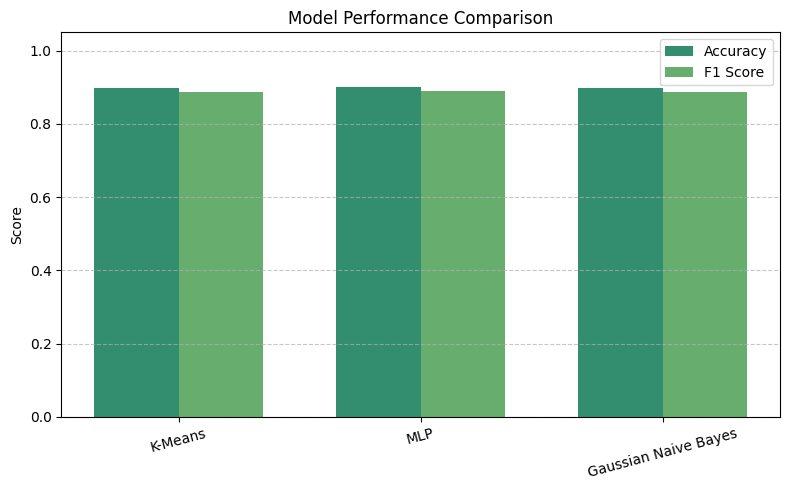

In [212]:
import numpy as np

x = np.arange(len(model_names))  # the label locations
width = 0.35  # width of the bars

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, accuracy_scores, width, label='Accuracy', color='#328E6E')
plt.bar(x + width/2, f1_scores, width, label='F1 Score', color='#67AE6E')

plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, model_names, rotation=15)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


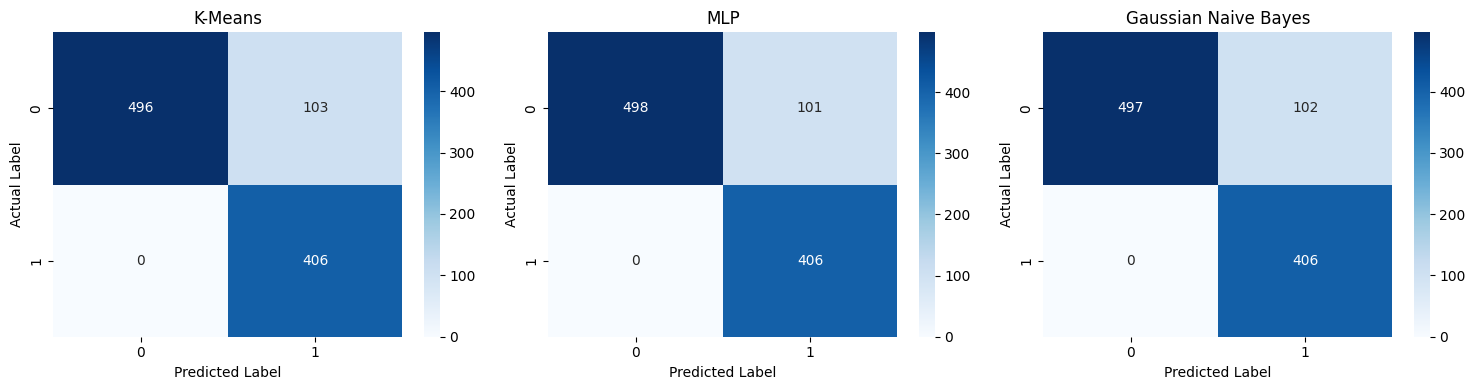

In [213]:

# ---------------------- Plot Confusion Matrices ---------------------- #
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes = axes.flatten()

for i, cm in enumerate(conf_matrices):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i])
    axes[i].set_title(model_names[i])
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("Actual Label")

plt.tight_layout()
plt.show()
